# Data

In [1]:
!ls yugioh

ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl


In [2]:
import pickle
import numpy as np
import os
import tqdm
import torch
import gc

from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()

from importlib import reload
from matplotlib import pyplot as plt

import matrix_approx_zeshel

matrix_approx_zeshel = reload(matrix_approx_zeshel)

!ls  | grep matrix_approx_zeshel

2023-08-23 21:34:50.431235: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-08-23 21:34:50.432545: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-08-23 21:34:50.459062: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-08-23 21:34:50.459638: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-23 21:34:50.897638: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

matrix_approx_zeshel.py


# Open Data loader & context

In [3]:
def load_ment_to_ent_scores(directory = "yugioh", shuffle_rows = 0):
    data = list()

    for file in os.listdir(directory):
        path = f"{directory}/{file}"
        print(f"Loading file {path}")
        with open(path, "rb") as f:
            data.append(
                pickle.load(f)
            )
    data = sorted(data, key = lambda x: x["arg_dict"]["n_ment_start"])

    for i in range(len(data) - 1):
        assert data[i]["arg_dict"]["n_ment_start"] + data[i]["arg_dict"]["n_ment"] == data[i + 1]["arg_dict"]["n_ment_start"]
        
    ment_to_ent_scores = list(map(lambda x: x["ment_to_ent_scores"], data))
    ment_to_ent_scores = np.vstack(ment_to_ent_scores)
    print("Loaded shape = ", ment_to_ent_scores.shape)
    
    if shuffle_rows:
        print(f"Shuffling... (seed = {shuffle_rows})")
        np.random.seed(shuffle_rows)
        np.random.shuffle(ment_to_ent_scores)
    
    return ment_to_ent_scores

In [4]:
class EvalContextRelevs:
    def __init__(self, relevs, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
        self.relevs = np.array(relevs)
        self.reqs_count = self.relevs.shape[0]
        self.games_count = self.relevs.shape[1]
        
        self.key_size = key_size
        self.key_games = (
            np.random.choice(np.arange(self.games_count), key_size, replace=False)
            if key_games is None else
            key_games
        )
        np.random.seed(seed)
        #np.random.shuffle(self.requests)

        self.try_det_attempts(det_attempts)
        self.train_split = int(self.reqs_count * train_size)

        assert key_size + 1 < self.train_split


        self.key_relevs = self.relevs[:key_size]
        self.train_relevs = self.relevs[key_size + 1: self.train_split]
        self.test_relevs = self.relevs[self.train_split:]

        self.slices = ["key", "train", "test"]
        print(len(self.key_relevs), len(self.train_relevs), len(self.test_relevs))

    def get_top_games(self):
        return self.relevs.mean(axis=0).argsort()[:100].numpy()

    def set_top_games_as_key(self):
        self.key_games = self.get_top_games()
        return self

    def try_det_attempts(self, det_attempts):
        def get_det(r):
            kr = r[:self.key_size, self.key_games] - r.mean()
            return np.abs(np.linalg.det(kr))

        best_i_array = np.arange(len(self.relevs))

        for i in range(det_attempts):

            r_i_array = np.arange(len(self.relevs))
            np.random.shuffle(r_i_array)

            n, o = get_det(self.relevs[r_i_array, :]), get_det(self.relevs[best_i_array, :])
            
            # print(f"try update key_reqs ({o} vs {n}...")
            if n > o:
                best_i_array = r_i_array
                print(f"updated det ({i}, {o} -> {n})")

        print("Best det = ", get_det(self.relevs[best_i_array, :]))

        self.relevs = self.relevs[best_i_array, :]
        print("Current de = ", get_det(self.relevs))
        
    def get_relevs(self, t = "train"):
        if t == "train":
            return self.train_relevs
        elif t == "key":
            return self.key_relevs
        elif t == "test":
            return self.test_relevs
        else:
            assert False
            
    def get_requests(self, t = "train"):
        if t == "train":
            return self.train_reqs
        elif t == "key":
            return self.key_reqs
        elif t == "test":
            return self.test_reqs
        else:
            assert False

In [5]:
# ctx = EvalContextRelevs(load_ment_to_ent_scores("yugioh", shuffle_rows=42), det_attempts=100)

# Games Data loader & context

In [6]:
import collections
import pickle
import numpy as np
import tqdm
import os
import gc

import matplotlib.pyplot as plt


def load(limit, raw_path = "stand/log.local.logtime2.txt", path = "log.local.logtime2.bin", key_games = None, seed = 17, det_attempts = 0):
    readvector = lambda s : np.array(list(map(float, s.strip()[1:-2].split(","))))
    requests = list()
    docembs = collections.defaultdict(dict)

    if os.path.isfile(path):
        with open(path, "rb") as f:
            flimit, frequests, fdocembs = pickle.load(f)
            if flimit == limit:
                requests, docembs = frequests, fdocembs
            else:
                print(f"WARN: buffered limit is different, {flimit} != {limit}, reloading...")

    if not requests:
        with open(raw_path) as f:
            req = list()
            reqid = None
            models = list()
            prevreqmodel = None
            reqmodel = dict()
            prevmodelid = -1
            bannermodelid = -1
            for i, line in tqdm.tqdm_notebook(enumerate(f)):
                if line.startswith("Model = 6;"):
                    prevreqmodel = reqmodel
                    reqmodel = dict()

                if line.startswith("Model = "):
                    spl = line.split(" ")
                    prevmodelid = int(spl[2][:-1])
                    bannermodelid = max(bannermodelid , prevmodelid)
                    reqmodel[prevmodelid] = readvector(spl[3])
                elif line.startswith("dbid"):
                    spl = line.split(" ")
                    dbid = int(spl[1][:-1])
                    docembs[bannermodelid][dbid] = readvector(spl[2])
                elif line.startswith("seed"):
                    if len(requests) >= limit:
                        break
                    if req:
                        requests.append((reqid, prevreqmodel, sorted(req)))
                        req = list()
                    reqid = "$_" + (line.split()[1] + "_" + line.split()[3])
                else:
                    req.append(
                        (int(line.split()[0]), float(line.split()[1]))
                    )
        
        with open(path, "wb") as f:
            pickle.dump((limit, requests, docembs), f)

    games_count = len(requests[0][2])
    assert games_count == 16514
    requests = [r for r in requests if len(r[2]) == games_count]
    
    print([(i, len(docembs[i].keys())) for i in docembs])  # should be equal
    docblocks = {
        mid : np.array([x[1] for x in sorted(list(docembs[mid].items()))])
        for mid in docembs
    }
    
    class EvalContext:
        def __init__(self, games_count = games_count, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
            self.games_count = games_count
            self.key_games = (
                np.random.choice(np.arange(games_count), key_size, replace=False)
                if key_games is None else
                key_games
            )

            self.requests = requests
            np.random.seed(seed)
            np.random.shuffle(self.requests)
            
            self.try_det_attempts(det_attempts)

            self.key_reqs = self.requests[:key_size + 1]
            self.key_reqs_idx = np.arange(key_size + 1)

            self.train_split = int(len(self.requests) * train_size)

            assert key_size + 1 < self.train_split

            self.train_reqs = self.requests[key_size + 1: self.train_split]
            self.test_reqs = self.requests[self.train_split:]

            self.slices = ["key", "train", "test"]
            print(len(self.key_reqs), len(self.train_reqs), len(self.test_reqs))

            self.docblocks = docblocks
            self.relevs = dict()
            
        def get_top_games(self):
            if not hasattr(self, "top_games"):
                embed_games = np.array([
                    np.array([r[2][g_i][1] for r in self.get_requests("train")])
                    for g_i in range(self.games_count)
                ])

                self.embed_games_mean = embed_games.mean(axis=1)
                self.top_games_all = (-self.embed_games_mean).argsort()
                self.top_games = self.top_games_all[:len(self.key_games)]

            return self.top_games
        
        def set_top_games_as_key(self):
            self.key_games = self.get_top_games()
            return self
        
        def try_det_attempts(self, det_attempts, model_id = 6):
            def get_det(r, r_i_array):
                kr = np.array([
                    r[r_i][1][model_id]
                    for r_i in r_i_array[:100]
                ])
                return np.abs(np.linalg.det(kr[:kr.shape[1], :]))

            best_i_array = np.arange(len(self.requests))

            for _ in range(det_attempts):
                # print("try update key_reqs...")
                
                r_i_array = np.arange(len(self.requests))
                np.random.shuffle(r_i_array)
                
                n, o = get_det(self.requests, r_i_array), get_det(self.requests, best_i_array)
                # print(n, o)
                if n > o:
                    best_i_array = r_i_array
                    # print("updated!")

            print("Best det = ", get_det(self.requests, best_i_array))
            
            new_requests = [
                self.requests[i]
                for i in best_i_array
            ]
            
            del self.requests
            gc.collect()

            self.requests = new_requests
            print(get_det(self.requests, np.arange(len(self.requests))))

        def get_relevs(self, t = "train"):
            if t not in self.relevs:
                self.relevs[t] = np.array([
                    np.array([g_i[1] for g_i in r[2]])
                    for r in self.get_requests(t)
                ])
                
            return self.relevs[t]

        def get_requests(self, t = "train"):
            if t == "train":
                return self.train_reqs
            elif t == "key":
                return self.key_reqs
            elif t == "test":
                return self.test_reqs
            else:
                assert False

    return EvalContext(key_games = key_games, seed = seed, det_attempts = det_attempts)

In [7]:
# ctx = load(L, raw_path = "stand/log.local.txt", seed=17, det_attempts=DA).set_top_games_as_key()

# Models

In [8]:
class Popular:
    def __init__(self, ctx):
        self.ctx = ctx
        self.game_avg_scores = {
            t : self.get_user_scores(t).mean(axis = 0)
            for t in self.ctx.slices
        }
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        return [self.top_logits for _ in self.get_user_scores(t)]
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

In [9]:
import tensorflow as tf
import copy
import tensorflow_ranking as tfr

DEFAULT_FIT_KWARGS = {
    "learning_rate": 0.001,
    "n": 500,
    "c": 5000,
    "matrix_l2": 0,
    "dssm_l2": 0,
    "train_popbias": False,
    "train_bias": False,
    "train_vbias": False,
    "verbose": True,
    "train_matrix": True,
    "train_dssm": False,
    "loss": "mse",
    "ubatch": 1e9,
    "activation": "relu",
    "score_verbose": 0,
    "trainable_items": False,
    "use_keys_in_train": False
}

class CBKnnV0(Popular):
    def __init__(self, ctx, fit_kwargs = dict()):
        super().__init__(ctx)
        
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(fit_kwargs)
        self.fit_kwargs = p
        
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        
        self.embed_users = {
            t : np.array([
                    np.array([r_i[i] for i in ctx.key_games])
                    for r_i in ctx.get_relevs(t)
                ])
            for t in ctx.slices
        }
        self.embed_users_mean = {
            t : self.embed_users[t].mean(axis = 0)
            for t in ctx.slices
        }
        # embed_users = embed_users - embed_users_mean
        print("self.embed_users['train'].shape = ", self.embed_users['train'].shape )
        
        self.embed_games = np.array([
            np.array([r[g_i] for r in ctx.get_relevs("key")])
            for g_i in range(ctx.games_count)
        ])
        
        self.embed_games_mean = self.embed_games.mean(axis = 0)
        
        # embed_games = embed_games - embed_games_mean
        print("self.embed_games.shape = ", self.embed_games.shape)
        
        
        if self.fit_kwargs["trainable_items"]:
            self.trainable_games = tf.Variable(
                tf.convert_to_tensor(self.embed_games, dtype=tf.float32),
                trainable=True
            )
        
        self.games_top_key = self.embed_games.mean(axis = 1)
        
        self.games2users = np.array([
            self.embed_games[g_i]
            for g_i in ctx.key_games
        ])
        print("self.games2users.shape = ", self.games2users.shape)
        
        self.core_users_scores = ctx.get_relevs("key")
        print("self.core_users_scores.shape = ", self.core_users_scores.shape)
        
        self.core_users_embs = self.embed_users["key"]
        print("self.core_users_embs.shape = ", self.core_users_embs.shape)
        
        self.ge_users = (
            (self.embed_users["train"].T / self.embed_users["train"].mean(axis=1)).T @ self.games2users
        )
        # ge_users = embed_users @ games2users
        print("self.ge_users.shape = ", self.ge_users.shape)
    
    def __repr__(self):
        return "CbKnn(" + str(self.fit_kwargs) + ")"
        
    # inherited   
    # def get_user_scores(self, t):
    
    def get_user_embs(self, t):
        return (self.embed_users[t] - self.embed_users_mean["train"]) / self.embed_users[t].std(axis=0)
        # return self.embed_users[t]
    
    def get_game_embs(self):
        if not self.fit_kwargs["trainable_items"]:
            return (self.embed_games - self.embed_games.mean(axis=0)) / self.embed_games.std(axis=0)
        else:
            return self.trainable_games
            
        #return self.embed_games

    def fit(self, **kwargs):
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        p.update(kwargs)

        self.p = p
        self.train_bias = p["train_bias"]
        self.train_vbias = p["train_vbias"]
        self.train_popbias = p["train_popbias"]
        self.train_matrix = p["train_matrix"]
        self.train_dssm = p["train_dssm"]
        self.loss = p["loss"]

        if p["use_keys_in_train"]:
            train_user_scores = np.vstack([
                self.get_user_scores("key"),
                self.get_user_scores("train")
            ])
            train_user_embs = np.vstack([
                self.get_user_embs("key"),
                self.get_user_embs("train")
            ])
        else:
            train_user_scores = self.get_user_scores("train")
            train_user_embs = self.get_user_embs("train")

        game_embs = self.get_game_embs()
        
        initializer = tf.keras.initializers.GlorotUniform()
        values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
        self.W = tf.Variable(values / 100., trainable = True) 
        self.pb = tf.Variable(1., trainable = True) 
        self.b = tf.Variable(0., trainable = True) 
        
        if p["verbose"]:
            print("self.W = ", self.W)
            print("0-loss = ", tf.reduce_mean((train_user_scores - 0) ** 2))
    
        opt =  tf.keras.optimizers.Adam(learning_rate=p["learning_rate"])

        if self.train_dssm:
            self.train_dssm = True

            dim = game_embs.shape[1]
            self.g_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.g_dssm(game_embs)
            
            # dim = train_user_embs.shape[1]
            self.u_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.u_dssm(train_user_embs)
            
        if self.train_vbias:
            self.vb = tf.Variable(
                np.zeros_like(self.game_avg_scores["train"], dtype=np.float32),
                trainable = True
            ) 
        
        
        for i in range(p["n"]):
            def loss():
                def get_logits_scores(loss_batch = 1e9):
                    game_slice = None
                    
                    ubatch = p["ubatch"]
                    if ubatch >= train_user_scores.shape[0]:
                        train_user_embs_ = train_user_embs
                        scores_ = train_user_scores
                    else:
                        u_slice = np.random.choice(np.arange(train_user_scores.shape[0]), ubatch, replace = True)
                        train_user_embs_ = train_user_embs[u_slice]
                        scores_ = train_user_scores[u_slice]
                    
                    if loss_batch >= game_embs.shape[0]:
                        game_embs_ = game_embs
                        scores_ = scores_
                    else:
                        game_slice = np.random.choice(np.arange(game_embs.shape[0]), loss_batch, replace = True)
                        game_embs_ = (
                            game_embs[game_slice]
                            if isinstance(game_embs, np.ndarray) else
                            tf.gather(game_embs, game_slice)
                        )
                        scores_ = scores_[:, game_slice]
                        
                    
                    logits = 0
                    
                    if self.train_matrix:
                        logits += train_user_embs_ @ self.W @ game_embs_.T

                    if self.train_dssm:
                        logits += self.u_dssm(train_user_embs_) @ tf.transpose(self.g_dssm(game_embs_))
                    
                    if self.train_popbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.pb * self.game_avg_scores["train"]
                        else:
                            logits += self.pb * self.game_avg_scores["train"][game_slice]
                        
                    if self.train_vbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.vb
                        else:
                            logits += tf.gather(self.vb, game_slice)
                        
                    if self.train_bias:
                        logits += self.b
                        
                    return logits, scores_
                        
                if self.loss == "mse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    v = tf.reduce_mean((scores - logits) ** 2)
                elif self.loss == "qmse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    q_mean = scores.mean(axis=1)
                    v = tf.reduce_mean(((scores.T - q_mean).T - logits) ** 2)
                elif self.loss == "ApproxNDCGLoss":
                    while True:
                        logits, scores = get_logits_scores(
                            loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))

                        v = tfr.keras.losses.ApproxNDCGLoss()(
                            scores.astype(np.float32),
                            logits
                        )
                    
                        if not tf.math.is_nan(v).numpy().any():
                            break
                        else:
                            if p["verbose"]:
                                print("nanloss ignored")
                elif self.loss == "softmax":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ))
                elif self.loss == "softmax_signed":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    sf = tf.nn.softmax(logits, axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        sf,
                        -sf
                    ))
                elif self.loss == "softmax_weighted":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ) * scores)
                elif self.loss == "sigmoid_top_100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    mask = np.argsort(-scores, axis=1) < 100
                    v = -tf.reduce_sum(
                        tf.math.log_sigmoid((2 * mask - 1) * logits)
                    )
                elif self.loss == "KL100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    mask = np.argsort(-scores, axis=1) < 100
                    v = tf.keras.losses.KLDivergence()((scores.T >= qs.T).T, logits)
                else:
                    assert False
                    
                if self.p["c"]:
                    v += tf.reduce_mean(self.W * self.W) * p["c"]
                    
                if self.p["dssm_l2"]:
                    for weights_ in [self.u_dssm.weights, self.g_dssm.weights]:
                        for weight_ in weights_:
                            v += tf.reduce_sum(weight_ * weight_) * self.p["dssm_l2"]
                
                if self.p["matrix_l2"]:
                    v += tf.reduce_sum(self.W * self.W) * self.p["matrix_l2"]
                
                if p["verbose"]:
                    print(v.numpy())
                
                return v

            weights = list()
            
            if self.train_matrix:
                weights += [self.W]

            if self.train_dssm:
                weights += self.u_dssm.weights
                weights += self.g_dssm.weights
            
            if self.train_popbias:
                weights += [self.pb]

            if self.train_vbias:
                weights += [self.vb]   
                
            if self.train_bias:
                weights += [self.b]   
                
            
            if self.p["trainable_items"]:
                weights += [self.trainable_games]
                
                
            opt.minimize(loss, weights)
            
            if p["score_verbose"] and (i % p["score_verbose"] == 0):
                print(f"\n=== Iteration {i} ===")
                for sl in self.ctx.slices:
                    print(f"slice = {sl}, score = {self.get_score(sl)}")
        print("last loss = ", loss())

    def recommend(self, t):
        logits = 0
                    
        if self.train_matrix:
            logits += self.get_user_embs(t) @ self.W @ tf.transpose(self.get_game_embs())

        if self.train_dssm:
            logits += self.u_dssm(self.get_user_embs(t)) @ tf.transpose(self.g_dssm(self.get_game_embs()))

        if self.train_popbias:
            logits += self.pb * self.game_avg_scores["train"]       
            
        if self.train_vbias:
            logits += self.vb
            
        if self.train_bias:
            logits += self.b
            
        return logits
    
    # inherited
    # def get_score(self, t, topsize = 100):
    
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [10]:
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [11]:
class AnnCUR(Popular):
    def __init__(self, ctx, oracle=False, key_games=None):
        super().__init__(ctx)
        self.oracle = oracle
        self.ctx = ctx

        self.key_cols_idx = np.array(sorted(ctx.key_games if key_games is None else key_games))
        rows_idx = np.arange(ctx.get_relevs("train").shape[0])
        
        self.cur = matrix_approx_zeshel.CURApprox(
            rows=torch.from_numpy(ctx.get_relevs("train")),
            cols=torch.from_numpy(ctx.get_relevs("train")[:, self.key_cols_idx]),
            row_idxs=rows_idx,
            col_idxs=self.key_cols_idx,
            approx_preference="rows",
            A=(torch.from_numpy(ctx.get_relevs("train")) if oracle else None)
        )        
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        key_relevs = torch.from_numpy(self.ctx.get_relevs(t)[:, self.key_cols_idx])
        return self.cur.get_complete_row(key_relevs)
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

# Evals

### open

In [14]:
ctx = EvalContextRelevs(load_ment_to_ent_scores("yugioh", shuffle_rows=42), det_attempts=100)
ctx.key_games

Loading file yugioh/ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
Loaded shape =  (3374, 10031)
Shuffling... (seed = 42)
updated det (4, 6.137885635798218e+30 -> 2.524378507319208e+32)
updated det (8, 2.524378507319208e+32 -> 5.48097506735188e+34)
updated det (11, 5.48097506735188e+34 -> 4.6749692824069873e+36)
Best det =  4.6749693e+36
Current de =  4.6749693e+36
100 2260 1013


array([1061, 6480, 8393, 4659, 7383, 5202, 8819, 4590, 6330, 3198, 4432,
       3290, 1684, 9299, 8683, 9847, 3941, 9056, 7010, 9880, 6488, 5896,
        638,   99, 8613, 8040, 6176, 8838, 2308,  353, 3831, 4404, 6205,
       2483, 2144, 7507, 4919, 1246, 4315, 9741, 8437, 9480, 3147, 2704,
       7958, 2348, 5238, 4963, 5035, 3963, 7641, 8425, 8565, 2420, 3684,
       9794, 4154, 3564, 3356, 6549, 2723, 2049, 2470, 4743, 2753, 1320,
       7556, 8173, 7667, 3680, 7515, 9031, 7043,  102, 1080,  993, 4531,
       6664, 5390, 1626, 9790, 9348, 6613, 1197, 3335,  518, 3231, 4165,
        181, 6659, 5078, 8483, 7535, 7019, 7330,  592, 2444, 6956, 7854,
       1368])

In [32]:
import numpy as np
from sklearn.decomposition import PCA
X = ctx.relevs.T
pca = PCA(n_components=2)
pca.fit(X)
Y = pca.transform(X)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.36953896 0.06491062]
[2985.9392 1251.4363]


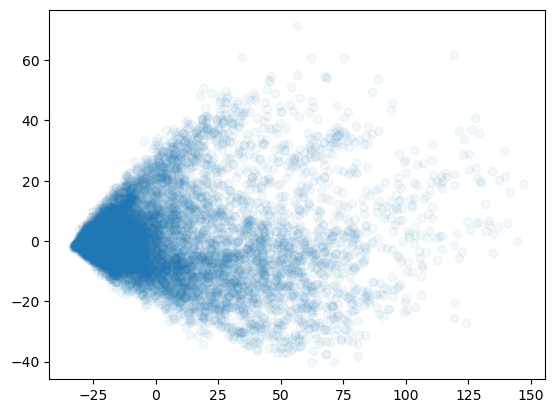

In [33]:
plt.scatter(Y[:, 0], Y[:, 1], alpha=0.05)

In [27]:
import numpy as np
from sklearn.manifold import TSNE
Y = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(X)

In [28]:
Y.shape

(10031, 2)

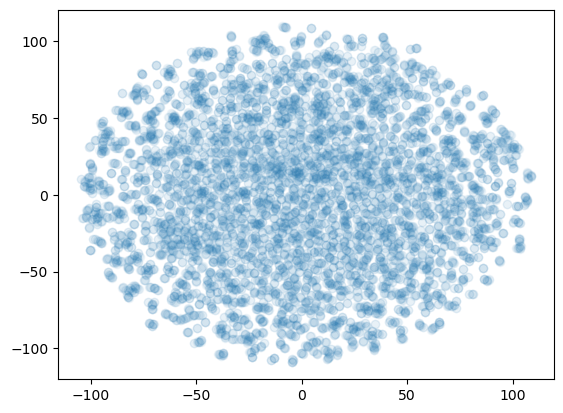

In [31]:
plt.scatter(Y[:, 0], Y[:, 1], alpha=0.05)

In [20]:
ev([
    Popular(ctx),
    AnnCUR(ctx),
    AnnCUR(ctx, key_games=np.arange(100)),
    AnnCUR(ctx, key_games=np.random.choice(np.arange(10031), size=100))
])

Loading file yugioh/ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
Loaded shape =  (3374, 10031)
Shuffling... (seed = 42)
updated det (4, 6.137885635798218e+30 -> 2.524378507319208e+32)
updated det (8, 2.524378507319208e+32 -> 5.48097506735188e+34)
updated det (11, 5.48097506735188e+34 -> 4.6749692824069873e+36)
Best det =  4.6749693e+36
Current de =  4.6749693e+36
100 2260 1013



model =  <__main__.Popular object at 0x7f56dd55a500>
np.mean(results), mse, len(results) =  0.0891637168141593 0.

### games

In [12]:
L = 7000
N = 1000
DA = 50

In [13]:
ctx = load(L, raw_path = "stand/log.local.txt", seed=17, det_attempts=DA).set_top_games_as_key()

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.628053728316076e-117
2.628053728316076e-117
101 4644 2034


In [14]:
ev([
    Popular(ctx),
    AnnCUR(ctx)
])




model =  <__main__.Popular object at 0x7fc31bf258a0>
np.mean(results), mse, len(results) =  0.5083527131782946 2.1090857474029794 4644
np.mean(results), mse, len(results) =  0.5076548672566372 2.214983388749716 2034
0.5083527131782946 0.5076548672566372



model =  <__main__.AnnCUR object at 0x7fc34592e6e0>
np.mean(results), mse, len(results) =  0.7693260120585702 0.5653017362404418 4644
np.mean(results), mse, len(results) =  0.762251720747296 0.5927785494345469 2034
0.7693260120585702 0.762251720747296


In [15]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            'score_verbose': 250,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 101)



model =  CbKnn({'learning_rate': 0.001, 'n': 1000, 'c': 0, 'dssm_l2': 0, 'train_popbias': False, 'train_bias': False, 'train_vbias': False, 'verbose': False, 'train_matrix': True, 'train_dssm': False, 'loss': 'ApproxNDCGLoss', 'ubatch': 1000000000.0, 'activation': 'relu', 'score_verbose': 250, 'trainable_items': False, 'loss_batch': 128, 'loss_q': 0.99})

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.3879207920792078 3.4351979925603247 101
slice = key, score = 0.3879207920792078
np.mean(results), mse, len(results) =  0.255671834625323 3.0989885305552813 4644
slice = train, score = 0.255671834625323
np.mean(results), mse, len(results) =  0.25862831858407076 3.2312721640242077 2034
slice = test, score = 0.25862831858407076

=== It

In [21]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            # 'loss_batch': 128,
            'loss_q': 0.99,
            'n': 100 + 0 * N,
            'score_verbose': 250,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 101)



model =  CbKnn({'learning_rate': 0.001, 'n': 100, 'c': 0, 'matrix_l2': 0, 'dssm_l2': 0, 'train_popbias': False, 'train_bias': False, 'train_vbias': False, 'verbose': False, 'train_matrix': True, 'train_dssm': False, 'loss': 'mse', 'ubatch': 1000000000.0, 'activation': 'relu', 'score_verbose': 250, 'trainable_items': False, 'loss_q': 0.99})

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.2415841584158416 5.561691579106369 101
slice = key, score = 0.2415841584158416
np.mean(results), mse, len(results) =  0.2325473729543497 5.1605327921278255 4644
slice = train, score = 0.2325473729543497
np.mean(results), mse, len(results) =  0.2385496558505408 5.31992812552234 2034
slice = test, score = 0.2385496558505408
last loss =  tf.Tensor(1.

In [22]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': False,
            'train_popbias': False,
            'train_bias': False,
            'train_vbias': True,
            'verbose': True, 'loss': 'mse',
            # 'loss_batch': 128,
            'loss_q': 0.99,
            'n': 100 + 0 * N,
            'score_verbose': 250,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 101)



model =  CbKnn({'learning_rate': 0.001, 'n': 100, 'c': 0, 'matrix_l2': 0, 'dssm_l2': 0, 'train_popbias': False, 'train_bias': False, 'train_vbias': True, 'verbose': True, 'train_matrix': True, 'train_dssm': False, 'loss': 'mse', 'ubatch': 1000000000.0, 'activation': 'relu', 'score_verbose': 250, 'trainable_items': False, 'loss_q': 0.99})
self.W =  <tf.Variable 'Variable:0' shape=(100, 101) dtype=float32, numpy=
array([[ 1.0795003e-03, -3.4555525e-04,  4.5205055e-05, ...,
        -3.0020357e-04,  1.4450076e-03,  1.6502268e-03],
       [-1.0344959e-03, -2.0879715e-04,  1.3788438e-03, ...,
        -8.7758453e-05, -5.5106694e-04, -1.6528593e-03],
       [-1.6720244e-03,  1.5225515e-04, -1.4333982e-03, ...,
        -1.4113450e-03, -2.4420366e-04,  

In [24]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': False,
            'train_popbias': False,
            'train_bias': False,
            'train_vbias': False,
            'verbose': True, 'loss': 'mse',
            'loss_batch': 1024,
            'loss_q': 0.99,
            'n': 1000 + 0 * N,
            'score_verbose': 250,
            'ubatch': 1024
        }
    )
])

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 101)



model =  CbKnn({'learning_rate': 0.001, 'n': 1000, 'c': 0, 'matrix_l2': 0, 'dssm_l2': 0, 'train_popbias': False, 'train_bias': False, 'train_vbias': False, 'verbose': True, 'train_matrix': True, 'train_dssm': False, 'loss': 'mse', 'ubatch': 1024, 'activation': 'relu', 'score_verbose': 250, 'trainable_items': False, 'loss_batch': 1024, 'loss_q': 0.99})
self.W =  <tf.Variable 'Variable:0' shape=(100, 101) dtype=float32, numpy=
array([[ 2.5061116e-04, -1.4391578e-03,  1.1836302e-03, ...,
        -6.2360021e-05,  4.5782328e-04, -1.3766079e-03],
       [-1.2391482e-03,  1.5418875e-03, -7.6049304e-04, ...,
        -1.1861786e-04, -1.0459028e-03,  1.1811566e-03],
       [-1.2594515e-03, -1.0152474e-03,  2.0355418e-04, ...,
         1.2867668e-03,  6.

3.4330980492717553
1.7420288709986602
1.71064869010107
1.4197301286439934
0.3976448188842016
2.3399447834380767
1.425007069971165
1.0301021469863478
1.132559837861891
1.6234304848987198
0.7754701780760971
1.17343292604962
1.3953263160001979
1.0179445130145168
1.8689390202814486
0.5902854830654776
3.1835976958821126
0.5475788067366523
1.382282388605813
1.614806375094837
1.3475902907587727
0.658633088041269
3.08703204352926
1.199531373798036
4.027766545800426
1.237731676564253
1.0798310262922497
2.8972960986447447
2.40979694897571
0.8779026874137266
0.7667850236138707
1.2044262528962746
1.2507248170282237
2.111526720193495
0.7735803498569324
0.9790739770944105
1.834625912261674
1.0277035762212092
1.1249961382108005
3.3862596100151285
1.3868894084788967
0.37718516991120504
2.527586789975
2.7621311187748865
2.3904134717281127
4.0446410919712665
0.5820717051497439
1.0020683406506108
1.120623451243641
1.0605440395326766
0.9435306323238255
6.563633700553111
1.213215212085799
4.641436375638254

2.490059438285385
1.4207174590583413
1.7725163984930756
0.7506898000432519
1.5035276059979115
4.486224071334114
0.9358800819755294
3.5417529592806347
1.8341314560947952
2.234890649057225
1.385927291319844
2.054029424365648
1.3589347123917686
1.4713153963131635

=== Iteration 750 ===
np.mean(results), mse, len(results) =  0.3875247524752476 2.6362436327489918 101
slice = key, score = 0.3875247524752476
np.mean(results), mse, len(results) =  0.34231266149870804 2.524358666302089 4644
slice = train, score = 0.34231266149870804
np.mean(results), mse, len(results) =  0.34782202556538844 2.686096595242754 2034
slice = test, score = 0.34782202556538844
0.6175567556639769
2.5906243223297083
9.997910004808926
10.965360629740784
10.470085119520741
0.9855683176283956
0.4506660536137501
0.685811518954248
1.9093819854472
1.1495338806476727
3.4602524126182432
0.26195353758041995
2.7417949341550054
4.257918289779762
0.6375203225127828
1.1553904338007706
3.249151375311458
1.1819515834335272
1.62219158

In [25]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 1e-6, 'train_dssm': False,
            'train_popbias': False,
            'train_bias': False,
            'train_vbias': False,
            'verbose': False, 'loss': 'mse',
            'loss_batch': 1024,
            'loss_q': 0.99,
            'n': 1000 + 0 * N,
            'score_verbose': 250,
            'ubatch': 1024
        }
    )
])

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 101)



model =  CbKnn({'learning_rate': 0.001, 'n': 1000, 'c': 1e-06, 'matrix_l2': 0, 'dssm_l2': 0, 'train_popbias': False, 'train_bias': False, 'train_vbias': False, 'verbose': False, 'train_matrix': True, 'train_dssm': False, 'loss': 'mse', 'ubatch': 1024, 'activation': 'relu', 'score_verbose': 250, 'trainable_items': False, 'loss_batch': 1024, 'loss_q': 0.99})

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.22940594059405942 5.53221555563387 101
slice = key, score = 0.22940594059405942
np.mean(results), mse, len(results) =  0.22153531438415158 5.236386169362179 4644
slice = train, score = 0.22153531438415158
np.mean(results), mse, len(results) =  0.22758603736479843 5.395955499368498 2034
slice = test, score = 0.22758603736479843

==

In [29]:
# KEY-TRAIN
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 1e-6, 'train_dssm': False,
            'train_popbias': False,
            'train_bias': False,
            'train_vbias': False,
            'verbose': False, 'loss': 'mse',
            'loss_batch': 1024,
            'loss_q': 0.99,
            'n': 1000 + 0 * N,
            'score_verbose': 250,
            'ubatch': 1024
        }
    )
])

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 101)



model =  CbKnn({'learning_rate': 0.001, 'n': 1000, 'c': 1e-06, 'matrix_l2': 0, 'dssm_l2': 0, 'train_popbias': False, 'train_bias': False, 'train_vbias': False, 'verbose': False, 'train_matrix': True, 'train_dssm': False, 'loss': 'mse', 'ubatch': 1024, 'activation': 'relu', 'score_verbose': 250, 'trainable_items': False, 'loss_batch': 1024, 'loss_q': 0.99})

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.31297029702970297 3.0246836609450214 101
slice = key, score = 0.31297029702970297
np.mean(results), mse, len(results) =  0.312125322997416 2.9689617263694172 4644
slice = train, score = 0.312125322997416
np.mean(results), mse, len(results) =  0.3226450344149459 3.0696092114106857 2034
slice = test, score = 0.3226450344149459

=== 

In [34]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            'score_verbose': 250,
            'use_keys_in_train': True
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4644, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4644, 101)



model =  CbKnn({'learning_rate': 0.001, 'n': 1000, 'c': 0, 'matrix_l2': 0, 'dssm_l2': 0, 'train_popbias': False, 'train_bias': False, 'train_vbias': False, 'verbose': False, 'train_matrix': True, 'train_dssm': False, 'loss': 'ApproxNDCGLoss', 'ubatch': 1000000000.0, 'activation': 'relu', 'score_verbose': 250, 'trainable_items': False, 'use_keys_in_train': True, 'loss_batch': 128, 'loss_q': 0.99})

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.2820792079207921 3.8999551354417687 101
slice = key, score = 0.2820792079207921
np.mean(results), mse, len(results) =  0.2293776916451335 3.9513239764931445 4644
slice = train, score = 0.2293776916451335
np.mean(results), mse, len(results) =  0.23180432645034413 4.095102659112035 2034
slice

In [ ]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            'score_verbose': 250,
            'use_keys_in_train': True,
            # 'ubatch': 512
        }
    )
])